# BI_Project: clustering Open Dataset

K vs silhouette:
  K=2: silhouette=0.3669
  K=3: silhouette=0.3574
  K=4: silhouette=0.3641
  K=5: silhouette=0.3992
  K=6: silhouette=0.3993
  K=7: silhouette=0.3839
  K=8: silhouette=0.3522
  K=9: silhouette=0.3412
  K=10: silhouette=0.3329

Elbow (knee) on inertia: 5
Best silhouette:         6
Chosen K:                5


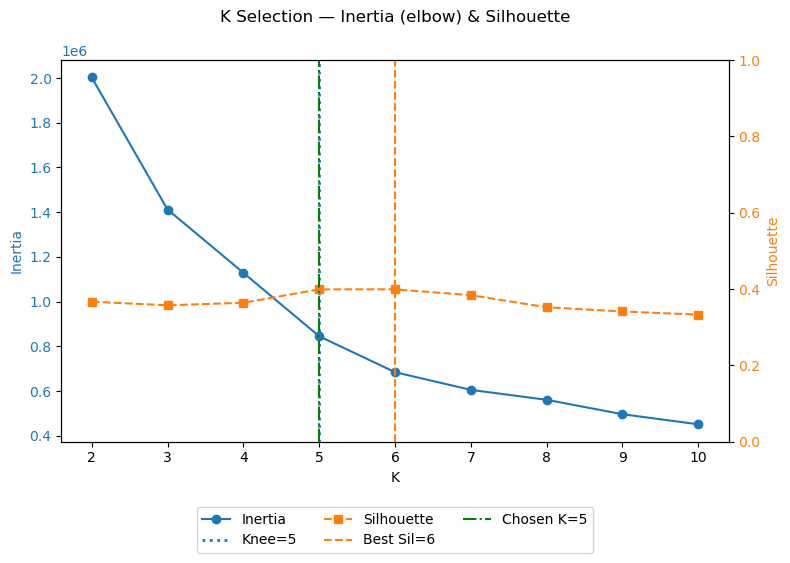

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\k_selection.png


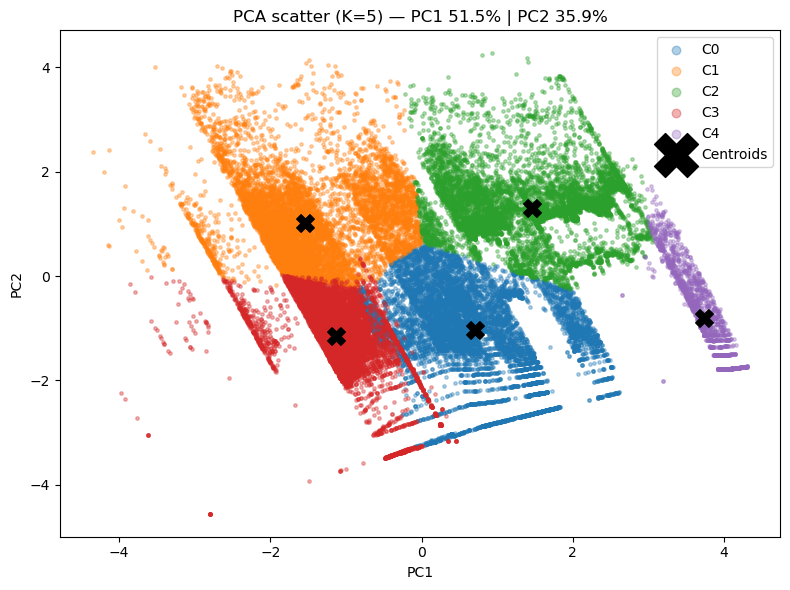

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\pca_scatter.png


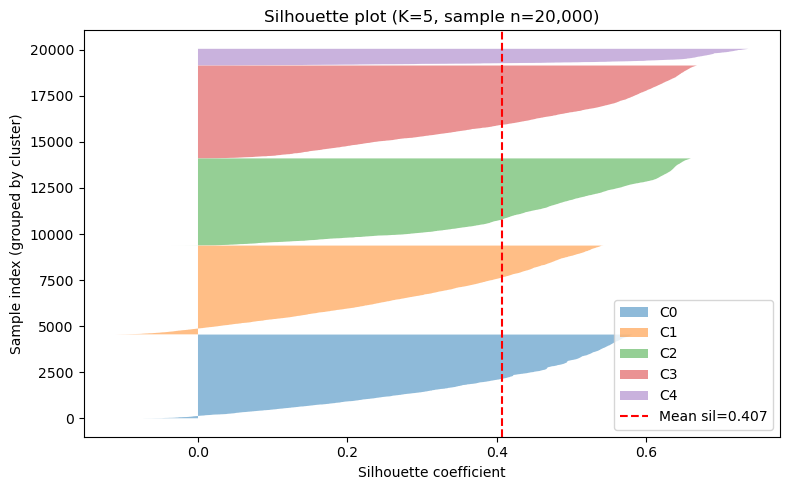

[INFO] Saved: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\silhouette_plot.png
[INFO] Exported clustered dataset to: C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering_results.csv

== Cluster sizes ==
 cluster
0    143078
1    154759
2    151005
3    162538
4     27726
Name: count, dtype: int64

== Cluster profile (feature means) ==
          usage_total  age_days  since_update_days  usage_per_365  \
cluster                                                            
0              38.02    777.04             768.16          24.59   
1            2397.62    312.82             222.72        4079.38   
2            1121.61   1814.43            1799.13         242.14   
3              50.43    297.53             129.44          91.09   
4              35.70   3421.06            2677.15           3.78   

         staleness_ratio  
cluster                   
0                   0.97  
1                   0.64  
2                   0.99

In [3]:
%%time

# ================================
# Clustering with Elbow (Knee) + Silhouette + PCA Plots
# ================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score


# Try to import KneeLocator; if unavailable, we run without elbow
try:
    from kneed import KneeLocator
    HAVE_KNEE = True
except Exception as _:
    HAVE_KNEE = False
    print("[WARN] 'kneed' not available; elbow detection will be skipped. Use best silhouette instead.")

# -------------------------------
# 0) Config (EDIT THESE)
# -------------------------------
csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"     # <-- update to your CSV
out_dir  = os.path.dirname(csv_path)

# K range and sampling knobs (adjust if you need more speed)
K_min, K_max      = 2, 10
sil_sample_size   = 20_000     # for silhouette computations and silhouette-plot sample
pca_plot_samples  = 40_000     # how many points to render in the PCA scatter
random_state      = 42

# How to pick K when elbow != best silhouette: choose "knee" or "silhouette"
choose_k_policy   = "knee"     # <-- change to "silhouette" if you prefer

# Whether to also produce a silhouette plot for the chosen K (on a sample)
make_sil_plot     = True

# -------------------------------
# 1) Load CSV
# -------------------------------
df = pd.read_csv(csv_path)

# Required engineered columns from SQL (or compute them in Python beforehand)
required = ["usage_total","age_days","since_update_days","usage_per_365","staleness_ratio"]
missing  = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# -------------------------------
# 2) Build the model matrix
# -------------------------------
X = df[required].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Optional but recommended: stabilize skew on usage features
for col in ["usage_total", "usage_per_365"]:
    X[col] = np.log1p(np.clip(X[col].values, 0, None))

# Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(X).astype(np.float32, copy=False)

# -------------------------------
# 3) K Sweep with MiniBatchKMeans
# -------------------------------
rng = np.random.default_rng(random_state)
n  = Xs.shape[0]
sil_idx = rng.choice(n, size=min(sil_sample_size, n), replace=False)
Xs_sil  = Xs[sil_idx]

Ks        = list(range(K_min, K_max+1))
inertias  = []
silscores = []

for k in Ks:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init='auto',         # small during sweep
        batch_size=2048,
        max_iter=100,
        random_state=random_state
    )
    labels_mb = mbk.fit_predict(Xs)
    inertias.append(mbk.inertia_)
    silscores.append(silhouette_score(Xs_sil, labels_mb[sil_idx]))

# Elbow (knee) via kneed if available
if HAVE_KNEE:
    kneedle = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
    k_knee  = int(kneedle.knee) if kneedle.knee is not None else None
else:
    k_knee  = None

k_sil_best = Ks[int(np.argmax(silscores))]

# Choose K by policy
if choose_k_policy.lower() == "knee" and (k_knee is not None):
    best_k = k_knee
else:
    best_k = k_sil_best

print("K vs silhouette:")
for k, s in zip(Ks, silscores):
    print(f"  K={k}: silhouette={s:.4f}")
print(f"\nElbow (knee) on inertia: {k_knee}")
print(f"Best silhouette:         {k_sil_best}")
print(f"Chosen K:                {best_k}")

# -------------------------------
# 4) Plot + SAVE K-selection figure (elbow + silhouette)
# -------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
color1 = "tab:blue"
ax1.plot(Ks, inertias, "o-", color=color1, label="Inertia")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(Ks, silscores, "s--", color=color2, label="Silhouette")
ax2.set_ylabel("Silhouette", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1)

if k_knee is not None:
    ax1.axvline(k_knee, color=color1, ls=":",  lw=2,   label=f"Knee={k_knee}")
ax2.axvline(k_sil_best,  color=color2, ls="--", lw=1.5, label=f"Best Sil={k_sil_best}")
ax2.axvline(best_k,      color="green", ls="-.", lw=1.5, label=f"Chosen K={best_k}")

fig.suptitle("K Selection — Inertia (elbow) & Silhouette")
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
k_png = os.path.join(out_dir, "k_selection.png")
plt.savefig(k_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved: {k_png}")

# -------------------------------
# 5) Fit final KMeans accurately
# -------------------------------
kmeans = KMeans(n_clusters=best_k, n_init='auto', algorithm='elkan', random_state=random_state)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels

# -------------------------------
# 6) PCA for visualization (2D)
# -------------------------------
pca = PCA(n_components=2, random_state=random_state)
XY = pca.fit_transform(Xs)
df["pca_x"] = XY[:,0]
df["pca_y"] = XY[:,1]
evr = pca.explained_variance_ratio_

# PCA scatter (sampled) with centroids
plot_idx   = rng.choice(n, size=min(pca_plot_samples, n), replace=False)
XYp, lblp  = XY[plot_idx], labels[plot_idx]
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
for c in np.unique(lblp):
    m = (lblp == c)
    plt.scatter(XYp[m,0], XYp[m,1], s=6, alpha=0.35, label=f"C{c}")
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="black", s=160, marker="X", label="Centroids")
plt.title(f"PCA scatter (K={best_k}) — PC1 {evr[0]*100:.1f}% | PC2 {evr[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(frameon=True, markerscale=2.5)
plt.tight_layout()
pca_png = os.path.join(out_dir, "pca_scatter.png")
plt.savefig(pca_png, dpi=150)
plt.show()
print(f"[INFO] Saved: {pca_png}")

# -------------------------------
# 7) Optional: silhouette plot at chosen K (on sample)
# -------------------------------
if make_sil_plot:
    Xs_sp    = Xs[sil_idx]
    lbl_sp   = labels[sil_idx]
    sil_vals = silhouette_samples(Xs_sp, lbl_sp)

    y_lower = 10
    plt.figure(figsize=(8,5))
    for c in sorted(np.unique(lbl_sp)):
        c_sil  = np.sort(sil_vals[lbl_sp == c])
        size_c = c_sil.shape[0]
        y_upper = y_lower + size_c
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.5, label=f"C{c}")
        y_lower = y_upper + 10

    mean_sil = float(np.mean(sil_vals))
    plt.axvline(mean_sil, color="red", ls="--", label=f"Mean sil={mean_sil:.3f}")
    plt.xlabel("Silhouette coefficient"); plt.ylabel("Sample index (grouped by cluster)")
    plt.title(f"Silhouette plot (K={best_k}, sample n={len(sil_vals):,})")
    plt.legend(frameon=True)
    plt.tight_layout()
    sil_png = os.path.join(out_dir, "silhouette_plot.png")
    plt.savefig(sil_png, dpi=150)
    plt.show()
    print(f"[INFO] Saved: {sil_png}")

# -------------------------------
# 8) Export enriched CSV for Power BI
# -------------------------------
out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[INFO] Exported clustered dataset to: {out_csv}")

# -------------------------------
# 9) Quick console profile
# -------------------------------
sizes   = df["cluster"].value_counts().sort_index()
profile = df.groupby("cluster")[required].mean().round(2)
print("\n== Cluster sizes ==\n", sizes)
print("\n== Cluster profile (feature means) ==\n", profile)

In [ ]:

# -------------------------------
# 0) Paths & knobs
# -------------------------------
csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"  
out_dir  = os.path.dirname(csv_path)

# sampling knobs for speed on large data
sil_sample_size   = 50_000     # for silhouette & silhouette plot
pca_plot_samples  = 80_000     # for PCA scatter
random_state      = 42
K_min, K_max      = 2, 10

# -------------------------------
# 1) Load data
# -------------------------------
df = pd.read_csv(csv_path)

# Ensure required columns exist (adjust names as per your SQL view)
req_cols = ["usage_total", "age_days", "since_update_days", "usage_per_365", "staleness_ratio"]
missing = [c for c in req_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

csv_path = r"C:\data\GitHub\BZIA_VM\ETL\BI_Project\Datadrop\DatasetClustering\Open_Data_Clustering.csv"
df = pd.read_csv(csv_path)
df.head()

out_dir  = os.path.dirname(csv_path)

# sampling knobs for speed on large data
sil_sample_size   = 50_000     # for silhouette & silhouette plot
pca_plot_samples  = 80_000     # for PCA scatter
random_state      = 42
K_min, K_max      = 2, 10


In [ ]:
df.info()

In [ ]:

# -------------------------------
# 2) Feature matrix
# -------------------------------
X = df[req_cols].copy()

# Clean & optional transforms
X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Log-transform skewed usage fields (recommended)
for col in ["usage_total", "usage_per_365"]:
    X[col] = np.log1p(np.clip(X[col].values, 0, None))

# Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(X).astype(np.float32, copy=False)

In [ ]:
%%time

# -------------------------------
# 3) K sweep (MiniBatchKMeans)
# -------------------------------
rng = np.random.default_rng(random_state)
n = Xs.shape[0]
sil_idx = rng.choice(n, size=min(sil_sample_size, n), replace=False)
Xs_sil = Xs[sil_idx]

Ks = list(range(K_min, K_max+1))
inertias, sils = [], []

for k in Ks:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        n_init=5,            # small during sweep
        batch_size=2048,
        max_iter=100,
        random_state=random_state
    )
    labels_mb = mbk.fit_predict(Xs)
    inertias.append(mbk.inertia_)
    sils.append(silhouette_score(Xs_sil, labels_mb[sil_idx]))

# Knee (elbow) on inertia
kneedle = KneeLocator(Ks, inertias, curve='convex', direction='decreasing')
k_knee  = int(kneedle.knee) if kneedle.knee is not None else None

# Silhouette best
k_sil_best = Ks[int(np.argmax(sils))]

# Choose K
if choose_k_policy.lower() == "knee" and (k_knee is not None):
    best_k = k_knee
else:
    best_k = k_sil_best

print("K vs silhouette:")
for k, s in zip(Ks, sils):
    print(f"  K={k}: silhouette={s:.4f}")
print(f"\nElbow (knee) on inertia: {k_knee}")
print(f"Best silhouette:         {k_sil_best}")
print(f"Chosen K:                {best_k}")

In [ ]:

# -------------------------------
# 4) Plot & SAVE elbow (knee) + silhouette together
# -------------------------------
fig, ax1 = plt.subplots(figsize=(8,5))
color1 = "tab:blue"
ax1.plot(Ks, inertias, "o-", color=color1, label="Inertia")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:orange"
ax2.plot(Ks, sils, "s--", color=color2, label="Silhouette")
ax2.set_ylabel("Silhouette", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1)

if k_knee is not None:
    ax1.axvline(k_knee, color=color1, ls=":", lw=2, label=f"Knee={k_knee}")
ax2.axvline(k_sil_best, color=color2, ls="--", lw=1.5, label=f"Best Sil={k_sil_best}")
ax2.axvline(best_k, color="green", ls="-.", lw=1.5, label=f"Chosen K={best_k}")

fig.suptitle("K selection — Inertia (elbow) & Silhouette")
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
k_png = os.path.join(out_dir, "k_selection.png")
plt.savefig(k_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"[INFO] Saved: {k_png}")



In [ ]:

# -------------------------------
# 5) Fit final accurate KMeans
# -------------------------------
kmeans = KMeans(n_clusters=best_k, n_init='auto', algorithm='elkan', random_state=random_state)
labels = kmeans.fit_predict(Xs)
df["cluster"] = labels


In [ ]:

# -------------------------------
# 6) PCA (2D) and scatter plot
# -------------------------------
pca = PCA(n_components=2, random_state=random_state)
XY = pca.fit_transform(Xs)
df["pca_x"] = XY[:, 0]
df["pca_y"] = XY[:, 1]
evr = pca.explained_variance_ratio_

plot_idx = rng.choice(n, size=min(pca_plot_samples, n), replace=False)
XYp  = XY[plot_idx]
lblp = labels[plot_idx]
centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))
for c in np.unique(lblp):
    m = (lblp == c)
    plt.scatter(XYp[m,0], XYp[m,1], s=6, alpha=0.35, label=f"C{c}")
plt.scatter(centers_2d[:,0], centers_2d[:,1], c="black", s=160, marker="X", label="Centroids")
plt.title(f"PCA scatter (K={best_k}) — PC1 {evr[0]*100:.1f}% | PC2 {evr[1]*100:.1f}%")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(frameon=True, markerscale=2.5)
plt.tight_layout()
pca_png = os.path.join(out_dir, "pca_scatter.png")
plt.savefig(pca_png, dpi=150)
plt.show()
print(f"[INFO] Saved: {pca_png}")

In [ ]:

# -------------------------------
# 7) Optional silhouette plot at chosen K (sample)
# -------------------------------
if make_sil_plot:
    sp_idx   = sil_idx  # reuse
    Xs_sp    = Xs[sp_idx]
    lbl_sp   = labels[sp_idx]
    sil_vals = silhouette_samples(Xs_sp, lbl_sp)

    y_lower = 10
    plt.figure(figsize=(8,5))
    for c in sorted(np.unique(lbl_sp)):
        c_sil = np.sort(sil_vals[lbl_sp == c])
        size_c = c_sil.shape[0]
        y_upper = y_lower + size_c
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.5, label=f"C{c}")
        y_lower = y_upper + 10

    mean_sil = float(np.mean(sil_vals))
    plt.axvline(mean_sil, color="red", ls="--", label=f"Mean sil={mean_sil:.3f}")
    plt.xlabel("Silhouette coefficient"); plt.ylabel("Sample index (grouped by cluster)")
    plt.title(f"Silhouette plot (K={best_k}, sample n={len(sil_vals):,})")
    plt.legend(frameon=True)
    plt.tight_layout()
    sil_png = os.path.join(out_dir, "silhouette_plot.png")
    plt.savefig(sil_png, dpi=150)
    plt.show()
    print(f"[INFO] Saved: {sil_png}")


In [ ]:

# -------------------------------
# 8) Export enriched CSV for Power BI
# -------------------------------
out_csv = os.path.splitext(csv_path)[0] + "_results.csv"
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"[INFO] Exported clustered dataset to: {out_csv}")

In [ ]:

# -------------------------------
# 9) Quick console profile
# -------------------------------
sizes = df["cluster"].value_counts().sort_index()
profile = df.groupby("cluster")[req_cols].mean().round(2)
print("\n== Cluster sizes ==\n", sizes)
print("\n== Cluster profile (feature means) ==\n", profile)
